In [ ]:
# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

pd.set_option('display.max_columns', None)

## Set working directory to tree_growth_metaanalysis_snmc
os.chdir('../../')

In [2]:
from Inventory_data_processing.Code.config import *
from Inventory_data_processing.Code.inventory_processing_functions import *

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# Import tree-level data from data archive

In [3]:
# Package ID: edi.2104.1 Cataloging System:https://pasta.edirepository.org.
# Data set title: The Fire and Fire Surrogate Study: Berkeley Forests, 2001-2020.
# Data set creator:  Scott Stephens - University of California, Berkeley 
# Data set creator:  Robert York - University of California, Berkeley 
# Data set creator:  Ariel Roughton - University of California, Berkeley 
# Data set creator:  John Battles - University of California, Berkeley 
# Data set creator:  Brandon Collins - University of California, Berkeley 
# Metadata Provider:  Yihong Zhu - University of California, Berkeley 
# Metadata Provider:  Helena Kleiner - University of California, Berkeley 
# Contact:  John Battles - Professor of Forest Ecology University of California, Berkeley  - jbattles@berkeley.edu
# Stylesheet v1.3 for metadata conversion into program: John H. Porter, Univ. Virginia, jporter@virginia.edu      
# 
# This cell, excerpted from the data archive, creates a PANDA dataframe for the "trees" data table. 
# For the tree growth meta-analysis, we do not use the "fuels," "shrub," or "forb_grass" data tables.


infile1  ="https://pasta.lternet.edu/package/data/eml/edi/2104/1/2d5563ed288ac5396add9b78fbca810b".strip() 
infile1  = infile1.replace("https://","http://")

dt1 =pd.read_csv(infile1 
          ,storage_options={'User-Agent':'EDI_CodeGen'}
          ,skiprows=1
            ,sep=","  
                ,quotechar='"' 
           , names=[
                    "treatment",     
                    "comp",     
                    "plot_id",     
                    "timestep",     
                    "tree_id",     
                    "status",     
                    "species",     
                    "dbh_cm",     
                    "height_m",     
                    "htcb_m",     
                    "crown_ratio",     
                    "tph"    ]
                 ,na_values={
                  'htcb_m':[
                          'NA',],
                  'crown_ratio':[
                          'NA',],} 
            
    )

# Coerce the data into the types specified in the metadata  
dt1.treatment=dt1.treatment.astype('category')  
dt1.comp=dt1.comp.astype('category')  
dt1.plot_id=dt1.plot_id.astype('category')  
dt1.timestep=dt1.timestep.astype('category')  
dt1.tree_id=dt1.tree_id.astype('category')  
dt1.status=dt1.status.astype('category')  
dt1.species=dt1.species.astype('category') 
dt1.dbh_cm=pd.to_numeric(dt1.dbh_cm,errors='coerce') 
dt1.height_m=pd.to_numeric(dt1.height_m,errors='coerce') 
dt1.htcb_m=pd.to_numeric(dt1.htcb_m,errors='coerce') 
dt1.crown_ratio=pd.to_numeric(dt1.crown_ratio,errors='coerce') 
dt1.tph=pd.to_numeric(dt1.tph,errors='coerce') 

print("Here is a description of the data frame dt1 and number of lines\n")
print(dt1.info())
print("--------------------\n\n")                
print("Here is a summary of numerical variables in the data frame dt1\n")
print(dt1.describe())
print("--------------------\n\n")       

Here is a description of the data frame dt1 and number of lines

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20276 entries, 0 to 20275
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   treatment    20276 non-null  category
 1   comp         20276 non-null  category
 2   plot_id      20276 non-null  category
 3   timestep     20276 non-null  category
 4   tree_id      20276 non-null  category
 5   status       20276 non-null  category
 6   species      20276 non-null  category
 7   dbh_cm       20276 non-null  float64 
 8   height_m     20276 non-null  float64 
 9   htcb_m       19094 non-null  float64 
 10  crown_ratio  19094 non-null  float64 
 11  tph          20276 non-null  float64 
dtypes: category(7), float64(5)
memory usage: 1.3 MB
None
--------------------


Here is a summary of numerical variables in the data frame dt1

             dbh_cm      height_m        htcb_m   crown_ratio           tph
cou

# Preliminary data cleaning and filtering

In [4]:
# Check that category types are clean for important columns (look for null or strange values)
for cat in ['treatment','comp','plot_id','timestep','status','species']:
    print(cat)
    print(*dt1[cat].unique())
    print(dt1[cat].dtype)
print("Total number of plots")
print(len(dt1['plot_id'].unique()))
print("Total number of trees")
print(len(dt1['tree_id'].unique()))

treatment
mech burn control mechburn
category
comp
490 340 40 240 590 190 60 180 400 380 570 350
category
plot_id
0490-00104 0490-00120 0340-00006 0490-00035 0490-00018 0340-00114 0490-00105 0040-00112 0040-00108 0340-00104 0490-00115 0340-00121 0490-00122 0490-00042 0490-00117 0340-00026 0490-00110 0240-00106 0590-00101 0490-00102 0190-00025 0490-00126 0590-00117 0490-00124 0190-00027 0590-00005 0190-00113 0040-00111 0040-00109 0040-00114 0040-00105 0040-00115 0040-00104 0040-00007 0040-00110 0240-00026 0040-00103 0040-00101 0240-00104 0040-00106 0240-00114 0240-00107 0240-00102 0040-00005 0240-00101 0240-00005 0240-00112 0590-00115 0240-00105 0240-00110 0040-00113 0040-00107 0240-00003 0040-00116 0240-00022 0590-00013 0590-00106 0340-00113 0340-00108 0340-00116 0340-00111 0190-00116 0340-00112 0340-00013 0240-00007 0240-00115 0190-00104 0190-00114 0490-00008 0190-00010 0190-00102 0190-00111 0490-00004 0190-00110 0340-00117 0340-00122 0340-00123 0060-00027 0040-00012 0340-00115 0180-0

In [5]:
# Map timesteps to inventory year
invntry_yr_dict = {
    'pre_treatment': 2001,
    'post_1': 2003,
    'post_7': 2009,
    'post_14': 2016,
    'post_18': 2020}

# Add a Year column
dt1['year'] = [invntry_yr_dict[i] for i in dt1['timestep']]
dt1

,treatment,comp,plot_id,timestep,tree_id,status,species,dbh_cm,height_m,htcb_m,crown_ratio,tph,year
0,mech,490,0490-00104,post_7,0490-00104-X09,Live,CONU,1.000,2.700000,0.961158,0.644016,246.913580,2009
1,mech,490,0490-00120,post_18,0490-00120-31,Live,CONU,0.254,1.490259,0.530509,0.644016,24.691358,2020
2,burn,340,0340-00006,post_18,0340-00006-54,Live,CONU,2.794,2.692847,0.958612,0.644016,24.691358,2020
3,mech,490,0490-00120,post_18,0490-00120-33,Live,CONU,1.778,2.211812,0.787371,0.644016,24.691358,2020
4,mech,490,0490-00120,post_18,0490-00120-24,Live,CONU,0.508,1.610518,0.573319,0.644016,24.691358,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20271,mechburn,570,0570-00106,pre_treatment,0570-00106-8,Snag,OTHER,65.300,6.100000,NaN,NaN,24.691360,2001
20272,burn,400,0400-00112,post_18,0400-00112-23,Snag,OTHER,23.368,3.352800,NaN,NaN,24.691360,2020
20273,mechburn,570,0570-00106,post_1,0570-00106-8,Snag,OTHER,65.300,6.100000,NaN,NaN,24.691360,2003
20274,mechburn,380,0380-00120,pre_treatment,0380-00120-1,Snag,OTHER,33.000,19.800000,NaN,NaN,24.691360,2001


In [6]:
# Set column variables

treeid_col = 'tree_id' # Tree ID
date_col = 'year' # Inventory date
dbh_col = 'dbh_cm' # DBH
species_col = 'species' # Species
status_col = 'status' # Life status
dead_ind = 'Snag' # Status value if tree is dead
live_ind = "Live" # Status value if tree is alive
date_incr = 'year' # Inventory date increment (day or year)
unit_col = 'comp' # Treatment unit ID
plotid_col = 'plot_id' # Plot ID
year_col = 'year' # Inventory Year

In [7]:
# How many unique trees, records at this point?
print("No. unique trees:", len(dt1[treeid_col].unique()))
print("No. records:", len(dt1))

No. unique trees: 8166
No. records: 20276


## Remove trees smaller than 15cm DBH

In [8]:
# For consistency with other sites in the meta-analysis,
# remove trees with diameters smaller than 15 cm

include_small = False

if include_small == False:
  # Include only trees larger than the global minimum measurement threshold across sites
  clean = dt1.loc[dt1[dbh_col] >=glbl_dbh_min].copy()
else:
    clean = dt1.copy()
clean

,treatment,comp,plot_id,timestep,tree_id,status,species,dbh_cm,height_m,htcb_m,crown_ratio,tph,year
23,burn,340,0340-00121,pre_treatment,0340-00121-8,Live,CONU,18.500,8.3000,2.6000,0.686747,24.691358,2001
46,control,240,0240-00106,pre_treatment,0240-00106-1,Live,CONU,27.900,18.9000,9.4000,0.502646,24.691358,2001
185,mech,490,0490-00122,pre_treatment,0490-00122-24,Live,CHCH,19.100,12.9000,5.8000,0.550388,24.691358,2001
190,mech,490,0490-00124,post_14,0490-00124-8,Live,CHCH,24.384,9.4488,2.7432,0.709677,24.691358,2016
194,mech,490,0490-00122,post_1,0490-00122-25,Live,CHCH,23.400,18.0000,8.8000,0.511111,24.691358,2003
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20271,mechburn,570,0570-00106,pre_treatment,0570-00106-8,Snag,OTHER,65.300,6.1000,NaN,NaN,24.691360,2001
20272,burn,400,0400-00112,post_18,0400-00112-23,Snag,OTHER,23.368,3.3528,NaN,NaN,24.691360,2020
20273,mechburn,570,0570-00106,post_1,0570-00106-8,Snag,OTHER,65.300,6.1000,NaN,NaN,24.691360,2003
20274,mechburn,380,0380-00120,pre_treatment,0380-00120-1,Snag,OTHER,33.000,19.8000,NaN,NaN,24.691360,2001


## Check for duplicated, null, and fill values

In [9]:
# Check for duplicated rows
dupes = clean.loc[clean.duplicated()]
assert len(dupes) == 0

# Check for trees that have more than one record for a given inventory year
nonpureDupes = clean.loc[clean[[treeid_col, 'year']].duplicated()]
assert len(nonpureDupes) == 0

# Check for null tree tags
assert len(clean[clean[treeid_col].isnull()])==0

# Examine data summary for weird values in DBH column (nulls, 999, 0...).
assert len(clean.loc[clean[dbh_col].isnull()])==0
clean.describe(include="all")

,treatment,comp,plot_id,timestep,tree_id,status,species,dbh_cm,height_m,htcb_m,crown_ratio,tph,year
count,13788,13788.0,13788,13788,13788,13788,13788,13788.000000,13788.000000,12617.000000,12617.000000,1.378800e+04,13788.000000
unique,4,12.0,219,5,3958,2,12,NaN,NaN,NaN,NaN,NaN,NaN
top,control,240.0,0240-00022,pre_treatment,0590-00118-6,Live,CADE,NaN,NaN,NaN,NaN,NaN,NaN
freq,5122,1870.0,237,3713,5,12662,4928,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.926091,20.905585,9.510972,0.547758,2.469136e+01,2008.633377
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.343178,10.811361,5.363686,0.157892,6.273922e-07,7.246390
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,1.370000,0.000000,0.020408,2.469136e+01,2001.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.900000,12.192000,5.500000,0.443983,2.469136e+01,2001.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.500000,18.288000,8.229600,0.551724,2.469136e+01,2009.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.400000,28.956000,12.700000,0.655738,2.469136e+01,2016.000000


In [10]:
# There are remeasurements on dead trees
# We'll removed these dead tree remeasurements later
print("Number of unique trees recorded as dead")
print(len(clean.loc[clean[status_col]==dead_ind, treeid_col].unique()))

print('Total number of dead tree records')
print(len(clean.loc[clean[status_col]==dead_ind]))

Number of unique trees recorded as dead
631
Total number of dead tree records
1126


In [11]:
# Reset index
clean.reset_index(inplace=True, drop=True)

# How many unique trees, records at this point?
print("No. unique trees:", len(clean[treeid_col].unique()))
print("No. records:", len(clean))

clean

No. unique trees: 3958
No. records: 13788


,treatment,comp,plot_id,timestep,tree_id,status,species,dbh_cm,height_m,htcb_m,crown_ratio,tph,year
0,burn,340,0340-00121,pre_treatment,0340-00121-8,Live,CONU,18.500,8.3000,2.6000,0.686747,24.691358,2001
1,control,240,0240-00106,pre_treatment,0240-00106-1,Live,CONU,27.900,18.9000,9.4000,0.502646,24.691358,2001
2,mech,490,0490-00122,pre_treatment,0490-00122-24,Live,CHCH,19.100,12.9000,5.8000,0.550388,24.691358,2001
3,mech,490,0490-00124,post_14,0490-00124-8,Live,CHCH,24.384,9.4488,2.7432,0.709677,24.691358,2016
4,mech,490,0490-00122,post_1,0490-00122-25,Live,CHCH,23.400,18.0000,8.8000,0.511111,24.691358,2003
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13783,mechburn,570,0570-00106,pre_treatment,0570-00106-8,Snag,OTHER,65.300,6.1000,NaN,NaN,24.691360,2001
13784,burn,400,0400-00112,post_18,0400-00112-23,Snag,OTHER,23.368,3.3528,NaN,NaN,24.691360,2020
13785,mechburn,570,0570-00106,post_1,0570-00106-8,Snag,OTHER,65.300,6.1000,NaN,NaN,24.691360,2003
13786,mechburn,380,0380-00120,pre_treatment,0380-00120-1,Snag,OTHER,33.000,19.8000,NaN,NaN,24.691360,2001


# Calculate individual tree growth over time

In [12]:
# Drop unnecessary columns
clean = clean.loc[:, ['treatment', 'comp', 'plot_id', 'year', 'timestep', 'tree_id', 'status', 'species', 'dbh_cm', 'tph']]

In [13]:
# Test tree_thru_time function
t = '0040-00116-21'
test_tree = tree_thru_time(t, clean,treeid_col, date_col, dbh_col, status_col,
                           dead_ind, date_incr)
test_tree

,treatment,comp,plot_id,year,timestep,tree_id,status,species,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year
856,control,40,0040-00116,2001,pre_treatment,0040-00116-21,Live,QUKE,32.000,24.691358,NaN,NaN,NaN,NaN,2001
1499,control,40,0040-00116,2003,post_1,0040-00116-21,Live,QUKE,32.800,24.691358,2.0,0.800,0.400000,2001.0,2003
627,control,40,0040-00116,2009,post_7,0040-00116-21,Live,QUKE,33.600,24.691358,6.0,0.800,0.133333,2003.0,2009
1013,control,40,0040-00116,2016,post_14,0040-00116-21,Live,QUKE,35.306,24.691358,7.0,1.706,0.243714,2009.0,2016
712,control,40,0040-00116,2020,post_18,0040-00116-21,Live,QUKE,35.052,24.691358,4.0,-0.254,-0.063500,2016.0,2020


In [14]:
# As a visual check, compare the output above to raw data
dt1.loc[dt1[treeid_col]==t]

,treatment,comp,plot_id,timestep,tree_id,status,species,dbh_cm,height_m,htcb_m,crown_ratio,tph,year
1774,control,40,0040-00116,post_7,0040-00116-21,Live,QUKE,33.600,13.9000,NaN,NaN,24.691358,2009
1908,control,40,0040-00116,post_18,0040-00116-21,Live,QUKE,35.052,24.9936,15.2400,0.390244,24.691358,2020
2119,control,40,0040-00116,pre_treatment,0040-00116-21,Live,QUKE,32.000,18.3000,12.8000,0.300546,24.691358,2001
2373,control,40,0040-00116,post_14,0040-00116-21,Live,QUKE,35.306,24.9936,14.3256,0.426829,24.691358,2016
3130,control,40,0040-00116,post_1,0040-00116-21,Live,QUKE,32.800,18.3000,12.8000,0.300546,24.691358,2003


In [15]:
# Calculate growth records for all trees
# Record trees associated with mismatched species or resurrections

spp_mismatch = []
resurrected = []
ddbh_df_wDead = pd.DataFrame({})


for tree in clean[treeid_col].unique(): # Loop through all trees
  # # Report progress
  # if tree_no % 1000 ==0:
  #   print(tree_no)

  # Get the individual tree's growth timeseries
  single_tree = tree_thru_time(tree,clean,treeid_col, date_col, dbh_col,
                               status_col, dead_ind, date_incr)

  # Append tree-specific data to site-wide list
  ddbh_df_wDead = pd.concat([ddbh_df_wDead,single_tree])

  # tree_no +=1
  # Add the tree to the appropriate list if it is associated with mismatched species or resurrections
  if mismatched_species(tree_df=single_tree,species_col=species_col):
    spp_mismatch.append(tree)
  if resurrected_trees(single_tree,status_col,live_ind=live_ind,dead_ind=dead_ind):
    resurrected.append(tree)
ddbh_df_wDead

,treatment,comp,plot_id,year,timestep,tree_id,status,species,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year
0,burn,340,0340-00121,2001,pre_treatment,0340-00121-8,Live,CONU,18.500,24.691358,NaN,NaN,NaN,NaN,2001
1,control,240,0240-00106,2001,pre_treatment,0240-00106-1,Live,CONU,27.900,24.691358,NaN,NaN,NaN,NaN,2001
2504,control,240,0240-00106,2003,post_1,0240-00106-1,Live,ABCO,28.700,24.691360,2.0,0.800,0.400000,2001.0,2003
3889,control,240,0240-00106,2016,post_14,0240-00106-1,Live,ABCO,32.766,24.691360,13.0,4.066,0.312769,2003.0,2016
2957,control,240,0240-00106,2020,post_18,0240-00106-1,Live,ABCO,33.020,24.691360,4.0,0.254,0.063500,2016.0,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13766,mechburn,570,0570-00107,2001,pre_treatment,0570-00107-9,Live,CADE,23.900,24.691360,NaN,NaN,NaN,NaN,2001
13775,mechburn,570,0570-00106,2001,pre_treatment,0570-00106-7,Snag,OTHER,23.600,24.691360,NaN,NaN,NaN,NaN,2001
13777,mechburn,380,0380-00127,2020,post_18,0380-00127-24,Snag,OTHER,22.606,24.691360,NaN,NaN,NaN,NaN,2020
13784,burn,400,0400-00112,2020,post_18,0400-00112-23,Snag,OTHER,23.368,24.691360,NaN,NaN,NaN,NaN,2020


## Resolve species mismatches

In [16]:
# Were there any trees with inconsistent species records?
print("Number of trees with mismatched species records:")
print(len(spp_mismatch))
print("Tree IDs with mismatched species")
print(spp_mismatch)

Number of trees with mismatched species records:
69
Tree IDs with mismatched species
['0240-00106-1', '0490-00124-8', '0490-00122-25', '0490-00018-17', '0490-00122-22', '0490-00124-16', '0490-00122-19', '0190-00113-12', '0490-00122-26', '0490-00124-17', '0490-00122-20', '0490-00122-21', '0190-00113-14', '0190-00113-11', '0190-00113-13', '0490-00124-7', '0040-00110-21', '0380-00125-14', '0040-00108-2', '0240-00113-6', '0240-00113-5', '0040-00101-1', '0060-00119-5', '0340-00013-3', '0040-00107-26', '0400-00023-3', '0040-00104-8', '0340-00114-13', '0340-00104-20', '0400-00118-12', '0040-00002-3', '0590-00104-13', '0040-00002-16', '0040-00003-25', '0040-00105-18', '0040-00003-17', '0060-00119-6', '0590-00009-20', '0040-00003-1', '0570-00115-17', '0340-00025-15', '0350-00117-10', '0350-00115-9', '0400-00102-24', '0340-00026-21', '0180-00110-4', '0400-00024-7', '0490-00126-7', '0190-00113-1', '0190-00116-2', '0240-00112-7', '0490-00041-9', '0400-00002-6', '0190-00010-25', '0190-00113-28', '0

In [17]:
# For trees with mismatched species, I take the latest inventory's species to be the correct one.

# Make a new species column, renaming the original that contains raw data
ddbh_df_wDead.rename(columns={species_col: "Species_raw"}, inplace=True)
ddbh_df_wDead[species_col] = ddbh_df_wDead['Species_raw']

# The most recent species record is taken to be the correct one
for t in spp_mismatch:
  t_ts = ddbh_df_wDead.loc[ddbh_df_wDead[treeid_col]==t]
  ddbh_df_wDead.loc[ddbh_df_wDead[treeid_col] == t, species_col] = t_ts.iloc[-1,:][species_col]

# Spot check
ddbh_df_wDead.loc[ddbh_df_wDead[treeid_col].isin(spp_mismatch)].tail(10)

,treatment,comp,plot_id,year,timestep,tree_id,status,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species
13787,mechburn,570,0570-00106,2001,pre_treatment,0570-00106-10,Snag,OTHER,24.100,24.69136,NaN,NaN,NaN,NaN,2001,OTHER
13772,mechburn,570,0570-00106,2003,post_1,0570-00106-10,Snag,OTHER,24.100,24.69136,2.0,NaN,NaN,2001.0,2003,OTHER
13425,mechburn,570,0570-00106,2009,post_7,0570-00106-10,Snag,CADE,25.000,24.69136,6.0,NaN,NaN,2003.0,2009,OTHER
13781,mechburn,570,0570-00106,2016,post_14,0570-00106-10,Snag,OTHER,25.654,24.69136,7.0,NaN,NaN,2009.0,2016,OTHER
13780,mechburn,570,0570-00106,2020,post_18,0570-00106-10,Snag,OTHER,24.384,24.69136,4.0,NaN,NaN,2016.0,2020,OTHER
13783,mechburn,570,0570-00106,2001,pre_treatment,0570-00106-8,Snag,OTHER,65.300,24.69136,NaN,NaN,NaN,NaN,2001,OTHER
13785,mechburn,570,0570-00106,2003,post_1,0570-00106-8,Snag,OTHER,65.300,24.69136,2.0,NaN,NaN,2001.0,2003,OTHER
13519,mechburn,570,0570-00106,2009,post_7,0570-00106-8,Snag,CADE,64.700,24.69136,6.0,NaN,NaN,2003.0,2009,OTHER
13779,mechburn,570,0570-00106,2016,post_14,0570-00106-8,Snag,OTHER,62.738,24.69136,7.0,NaN,NaN,2009.0,2016,OTHER
13776,mechburn,570,0570-00106,2020,post_18,0570-00106-8,Snag,OTHER,64.516,24.69136,4.0,NaN,NaN,2016.0,2020,OTHER


In [18]:
# Check that each unique tree is only associated with one species
tree_sp = ddbh_df_wDead.groupby([treeid_col,unit_col,species_col],as_index=False, observed = True).count()[[treeid_col,unit_col,species_col]]
assert len(tree_sp) == len(ddbh_df_wDead[treeid_col].unique())

## Resolve tree resurrections

In [19]:
# Were there any trees that were recorded as being resurrected?
print("Number of trees with resurrection records:")
print(len(resurrected))
print("Tree IDs with resurrection records")
print(resurrected)

Number of trees with resurrection records:
1
Tree IDs with resurrection records
['0400-00118-22']


In [20]:
# Examine the resurrected tree's timeseries
ddbh_df_wDead.loc[ddbh_df_wDead[treeid_col]=='0400-00118-22']

,treatment,comp,plot_id,year,timestep,tree_id,status,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species
12832,burn,400,0400-00118,2001,pre_treatment,0400-00118-22,Live,CADE,24.400,24.69136,NaN,NaN,NaN,NaN,2001,CADE
12652,burn,400,0400-00118,2003,post_1,0400-00118-22,Live,CADE,24.900,24.69136,2.0,0.5,0.25,2001.0,2003,CADE
12662,burn,400,0400-00118,2009,post_7,0400-00118-22,Snag,CADE,26.100,24.69136,6.0,1.2,0.20,2003.0,2009,CADE
11450,burn,400,0400-00118,2016,post_14,0400-00118-22,Snag,CADE,25.908,24.69136,7.0,NaN,NaN,2009.0,2016,CADE
11472,burn,400,0400-00118,2020,post_18,0400-00118-22,Live,CADE,25.908,24.69136,4.0,0.0,0.00,2016.0,2020,CADE


In [21]:
# I assume that the 2020 record is incorrect and that the tree is dead. 

# Make a new status column, renaming the original that contains raw data
ddbh_df_wDead.rename(columns={status_col: "Status_raw"}, inplace=True)
ddbh_df_wDead[status_col] = ddbh_df_wDead['Status_raw']

# Correct the status
ddbh_df_wDead.loc[(ddbh_df_wDead[treeid_col]=='0400-00118-22') & (ddbh_df_wDead[year_col]==2020), status_col] = dead_ind

## Drop remeasurements of dead trees

In [22]:
# Drop second (and further) records for dead trees
# I.e., retain only the first dead tree record
dead_ba_flag = []
for tree in ddbh_df_wDead[treeid_col].unique():
  one_tree = ddbh_df_wDead.loc[ddbh_df_wDead[treeid_col]==tree]
  for i in range(len(one_tree)):
    if i == 0:
      dead_ba_flag.append(0)
    elif (one_tree[status_col].iloc[i]==dead_ind) & (one_tree[status_col].iloc[i-1] == dead_ind):
      dead_ba_flag.append(1)
    else:
      dead_ba_flag.append(0)
ddbh_df_wDead['Remove flag'] = dead_ba_flag

In [23]:
## Some checks
check = ddbh_df_wDead.loc[ddbh_df_wDead['Remove flag']==1]
assert (check[status_col]==dead_ind).all() # All flagged trees are in fact dead
print(check['year'].unique()) # Can't be the first inventory year
check

[2020 2016 2009 2003]


,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag
280,control,40,0040-00115,2020,post_18,0040-00115-16,Snag,NODE,23.114,24.691358,4.0,NaN,NaN,2016.0,2020,NODE,Snag,1
72,control,40,0040-00110,2016,post_14,0040-00110-12,Snag,NODE,27.432,24.691358,7.0,NaN,NaN,2009.0,2016,NODE,Snag,1
585,burn,340,0340-00112,2009,post_7,0340-00112-2,Snag,NODE,21.700,24.691358,6.0,NaN,NaN,2003.0,2009,NODE,Snag,1
208,control,240,0240-00101,2003,post_1,0240-00101-14,Snag,NODE,21.600,24.691358,2.0,NaN,NaN,2001.0,2003,NODE,Snag,1
579,burn,340,0340-00112,2009,post_7,0340-00112-32,Snag,NODE,22.100,24.691358,6.0,NaN,NaN,2003.0,2009,NODE,Snag,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13716,mechburn,570,0570-00025,2016,post_14,0570-00025-18,Snag,CADE,25.654,24.691360,7.0,NaN,NaN,2009.0,2016,CADE,Snag,1
13785,mechburn,570,0570-00106,2003,post_1,0570-00106-8,Snag,OTHER,65.300,24.691360,2.0,NaN,NaN,2001.0,2003,OTHER,Snag,1
13519,mechburn,570,0570-00106,2009,post_7,0570-00106-8,Snag,CADE,64.700,24.691360,6.0,NaN,NaN,2003.0,2009,OTHER,Snag,1
13779,mechburn,570,0570-00106,2016,post_14,0570-00106-8,Snag,OTHER,62.738,24.691360,7.0,NaN,NaN,2009.0,2016,OTHER,Snag,1


In [24]:
# Drop remeasurements of dead trees
ddbh_df=ddbh_df_wDead.drop(ddbh_df_wDead.loc[ddbh_df_wDead['Remove flag']==1].index)
ddbh_df

,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag
0,burn,340,0340-00121,2001,pre_treatment,0340-00121-8,Live,CONU,18.500,24.691358,NaN,NaN,NaN,NaN,2001,CONU,Live,0
1,control,240,0240-00106,2001,pre_treatment,0240-00106-1,Live,CONU,27.900,24.691358,NaN,NaN,NaN,NaN,2001,ABCO,Live,0
2504,control,240,0240-00106,2003,post_1,0240-00106-1,Live,ABCO,28.700,24.691360,2.0,0.800,0.400000,2001.0,2003,ABCO,Live,0
3889,control,240,0240-00106,2016,post_14,0240-00106-1,Live,ABCO,32.766,24.691360,13.0,4.066,0.312769,2003.0,2016,ABCO,Live,0
2957,control,240,0240-00106,2020,post_18,0240-00106-1,Live,ABCO,33.020,24.691360,4.0,0.254,0.063500,2016.0,2020,ABCO,Live,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13766,mechburn,570,0570-00107,2001,pre_treatment,0570-00107-9,Live,CADE,23.900,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0
13775,mechburn,570,0570-00106,2001,pre_treatment,0570-00106-7,Snag,OTHER,23.600,24.691360,NaN,NaN,NaN,NaN,2001,OTHER,Snag,0
13777,mechburn,380,0380-00127,2020,post_18,0380-00127-24,Snag,OTHER,22.606,24.691360,NaN,NaN,NaN,NaN,2020,OTHER,Snag,0
13784,burn,400,0400-00112,2020,post_18,0400-00112-23,Snag,OTHER,23.368,24.691360,NaN,NaN,NaN,NaN,2020,OTHER,Snag,0


In [25]:
# Check that there are no null DBH measurements
assert len(ddbh_df.loc[ddbh_df[dbh_col].isnull()])==0

# Check that each dead tree is only associated with one death record
assert len(ddbh_df.loc[ddbh_df[status_col]==dead_ind]) == len(ddbh_df.loc[ddbh_df[status_col]==dead_ind, treeid_col].unique())

In [26]:
# How many unique trees, records at this point?
print("No. unique trees:", len(ddbh_df[treeid_col].unique()))
print("No. records:", len(ddbh_df))

No. unique trees: 3958
No. records: 13292


## Revise outliers for BA and SDI timeseries

Basal area (BA) and stand density index (SDI) calculations are based DBH measurements. If a DBH measurement represents an outlier, it will impact the BA calculation. However, dropping the outliers entirely would bias the BA estimate low. Thus, for records associated with growth outliers, I replace the “raw” DBH with an interpolated value based on the nearest non-outlying records.

I calculate growth increment outliers on a species-specific basis.

Outlier definition: mean annual DBH increment is >/< the species-specific mean +/- 3 standard deviations.

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, 'ABCO'),
  Text(1, 0, 'ACMA'),
  Text(2, 0, 'ALRH'),
  Text(3, 0, 'ARME'),
  Text(4, 0, 'CADE'),
  Text(5, 0, 'CHCH'),
  Text(6, 0, 'CONU'),
  Text(7, 0, 'NODE'),
  Text(8, 0, 'OTHER'),
  Text(9, 0, 'PILA'),
  Text(10, 0, 'PIPO'),
  Text(11, 0, 'PSME'),
  Text(12, 0, 'QUKE')])

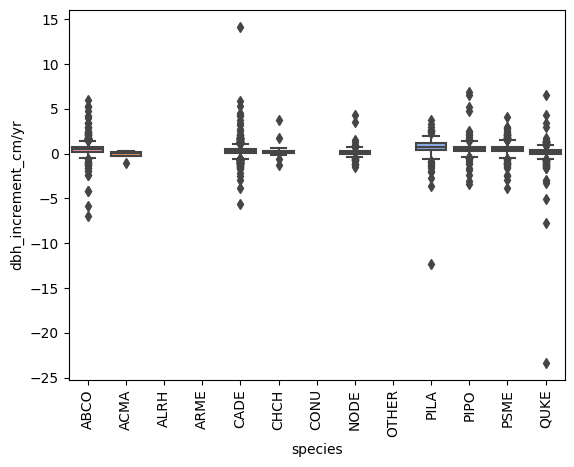

In [27]:
# Quick visualization of outliers
sns.boxplot(ddbh_df, y='dbh_increment_cm/yr', x=species_col)
plt.xticks(rotation = 90)

In [28]:
# Initial pass to identify outliers
outliers = pd.DataFrame()
sp = []
ll = []
ul = []
for s in ddbh_df[species_col].unique(): # Outliers are identified on a species basis
  sp.append(s)
  outs = id_outliers(ddbh_df, s,species_col)
  ll.append(outs[1])
  ul.append(outs[2])
  outliers = pd.concat([outliers, outs[0]])

# Create a lookup table that records the upper and lower growth limits for each species
outlier_dict = pd.DataFrame({'Species':sp,'Lower_limit':ll, 'Upper_limit':ul})
print(outlier_dict)
outliers

   Species  Lower_limit  Upper_limit
0     CONU          NaN          NaN
1     ABCO    -1.175181     2.179675
2     CHCH    -1.868773     2.497430
3     NODE    -1.090341     1.413939
4     ACMA    -2.047359     1.742324
5     QUKE    -3.431782     3.734534
6     PSME    -0.966013     2.023336
7     CADE    -1.261638     1.823562
8     PIPO    -1.317702     2.362295
9     PILA    -2.061865     3.479205
10   OTHER          NaN          NaN


,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag
1584,control,40,0040-00105,2003,post_1,0040-00105-16,Live,ABCO,51.300,24.69136,2.0,-3.800,-1.900000,2001.0,2003,ABCO,Live,0
3439,control,590,0590-00109,2009,post_7,0590-00109-9,Live,ABCO,73.000,24.69136,6.0,-14.100,-2.350000,2003.0,2009,ABCO,Live,0
4322,control,590,0590-00109,2016,post_14,0590-00109-9,Live,ABCO,97.282,24.69136,7.0,24.282,3.468857,2009.0,2016,ABCO,Live,0
1661,control,40,0040-00106,2009,post_7,0040-00106-11,Live,ABCO,57.400,24.69136,6.0,31.200,5.200000,2003.0,2009,ABCO,Live,0
2906,control,40,0040-00106,2016,post_14,0040-00106-11,Snag,ABCO,27.940,24.69136,7.0,-29.460,-4.208571,2009.0,2016,ABCO,Snag,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7816,control,590,0590-00113,2020,post_18,0590-00113-4,Snag,PIPO,55.880,24.69136,4.0,-6.350,-1.587500,2016.0,2020,PIPO,Snag,0
8220,mechburn,180,0180-00102,2020,post_18,0180-00102-2,Snag,PILA,84.074,24.69136,4.0,-14.478,-3.619500,2016.0,2020,PILA,Snag,0
8233,mechburn,180,0180-00102,2003,post_1,0180-00102-8,Live,PILA,110.000,24.69136,2.0,7.400,3.700000,2001.0,2003,PILA,Live,0
8337,mechburn,180,0180-00101,2003,post_1,0180-00101-31,Live,PILA,55.900,24.69136,2.0,-24.600,-12.300000,2001.0,2003,PILA,Live,0


Process for removing outliers (as implemented in the `remove_outliers` function):

1. If a tree has one or more outliers in its growth timeseries, drop the first outlier in the tree’s growth timeseries.
2. Recalculate the mean annual DBH increment for the remaining records
3. Check the adjusted timeseries for outliers
4. Repeat (1-3) until all the outliers have been removed
5. Replace original growth timeseries with adjusted one
6. Log which records were dropped

Checks:
If the first growth increment is the outlier, decide whether first or second record needs to be dropped
If mean growth in first AND third interval exceed that of the mean growth between interval 1 and 3, the second record is the outlier. Otherwise, it’s the first.

In [29]:
# Flag all outliers
flagged_outliers = manage_outliers(ddbh_df, outliers, outlier_dict,species_col,
                                treeid_col, dbh_col, year_col, date_col,
                                status_col, dead_ind, date_incr)
flagged_outliers

,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag,Outlier
0,burn,340,0340-00121,2001,pre_treatment,0340-00121-8,Live,CONU,18.500,24.691358,NaN,NaN,NaN,NaN,2001,CONU,Live,0,0
1,control,240,0240-00106,2001,pre_treatment,0240-00106-1,Live,CONU,27.900,24.691358,NaN,NaN,NaN,NaN,2001,ABCO,Live,0,0
2504,control,240,0240-00106,2003,post_1,0240-00106-1,Live,ABCO,28.700,24.691360,2.0,0.800,0.400000,2001.0,2003,ABCO,Live,0,0
3889,control,240,0240-00106,2016,post_14,0240-00106-1,Live,ABCO,32.766,24.691360,13.0,4.066,0.312769,2003.0,2016,ABCO,Live,0,0
2957,control,240,0240-00106,2020,post_18,0240-00106-1,Live,ABCO,33.020,24.691360,4.0,0.254,0.063500,2016.0,2020,ABCO,Live,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13766,mechburn,570,0570-00107,2001,pre_treatment,0570-00107-9,Live,CADE,23.900,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0
13775,mechburn,570,0570-00106,2001,pre_treatment,0570-00106-7,Snag,OTHER,23.600,24.691360,NaN,NaN,NaN,NaN,2001,OTHER,Snag,0,0
13777,mechburn,380,0380-00127,2020,post_18,0380-00127-24,Snag,OTHER,22.606,24.691360,NaN,NaN,NaN,NaN,2020,OTHER,Snag,0,0
13784,burn,400,0400-00112,2020,post_18,0400-00112-23,Snag,OTHER,23.368,24.691360,NaN,NaN,NaN,NaN,2020,OTHER,Snag,0,0


In [30]:
# Checks
# Did we retain all trees?
assert len(ddbh_df[treeid_col].unique()) == len(flagged_outliers[treeid_col].unique())

# Did we retain all records?
assert len(ddbh_df) == len(flagged_outliers)

# some extra code to sample individual trees to check
samps=random.sample(range(len(outliers[treeid_col].unique())),10)
trees_to_check = outliers[treeid_col].unique()[samps]
trees_to_check

['0040-00112-7', '0240-00115-30', '0040-00106-11', '0180-00102-2', '0570-00119-1', '0400-00102-24', '0350-00109-8', '0590-00109-9', '0380-00125-3', '0240-00003-8']
Categories (8166, object): ['0040-00002-1', '0040-00002-12', '0040-00002-14', '0040-00002-16', ..., '0590-00118-92', '0590-00118-93', '0590-00118-94', '0590-00118-x09']

In [31]:
# Use this and the following cell to check random trees where we have
# manipulated DBH for the BA calculation

# Random test tree that has a growth outlier
i = 0
test = flagged_outliers.loc[flagged_outliers[treeid_col]==trees_to_check[i]].iloc[:,]
test

,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag,Outlier
2313,control,40,0040-00112,2001,pre_treatment,0040-00112-7,Live,ABCO,79.500,24.69136,NaN,NaN,NaN,NaN,2001,ABCO,Live,0,0
3832,control,40,0040-00112,2003,post_1,0040-00112-7,Live,ABCO,76.700,24.69136,2.0,-2.800,-1.400000,2001.0,2003,ABCO,Live,0,1
2560,control,40,0040-00112,2009,post_7,0040-00112-7,Live,ABCO,80.900,24.69136,8.0,1.400,0.175000,2001.0,2009,ABCO,Live,0,0
3450,control,40,0040-00112,2016,post_14,0040-00112-7,Live,ABCO,83.566,24.69136,7.0,2.666,0.380857,2009.0,2016,ABCO,Live,0,0
3010,control,40,0040-00112,2020,post_18,0040-00112-7,Live,ABCO,84.328,24.69136,4.0,0.762,0.190500,2016.0,2020,ABCO,Live,0,0


In [32]:
# Test the fill_outlier function.
# Compare DBH column to DBH_BA column
# Need to use "year" column here
fill_outlier_dbh(test, dbh_col, treeid_col, year_col)

,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag,Outlier,DBH_BA
2313,control,40,0040-00112,2001,pre_treatment,0040-00112-7,Live,ABCO,79.500,24.69136,NaN,NaN,NaN,NaN,2001,ABCO,Live,0,0,79.500
3832,control,40,0040-00112,2003,post_1,0040-00112-7,Live,ABCO,76.700,24.69136,2.0,-2.800,-1.400000,2001.0,2003,ABCO,Live,0,1,79.850
2560,control,40,0040-00112,2009,post_7,0040-00112-7,Live,ABCO,80.900,24.69136,8.0,1.400,0.175000,2001.0,2009,ABCO,Live,0,0,80.900
3450,control,40,0040-00112,2016,post_14,0040-00112-7,Live,ABCO,83.566,24.69136,7.0,2.666,0.380857,2009.0,2016,ABCO,Live,0,0,83.566
3010,control,40,0040-00112,2020,post_18,0040-00112-7,Live,ABCO,84.328,24.69136,4.0,0.762,0.190500,2016.0,2020,ABCO,Live,0,0,84.328


In [33]:
# Loop through all the trees that have at least one outlier record and fill the DBHs associated with those records
trees_w_outliers = flagged_outliers.loc[flagged_outliers['Outlier']==1][treeid_col].unique()

filled_outliers = pd.DataFrame()

for t in trees_w_outliers:
  tree_df = flagged_outliers.loc[flagged_outliers[treeid_col]==t]
  filled_tree = fill_outlier_dbh(tree_df, dbh_col, treeid_col, year_col)
  filled_outliers = pd.concat([filled_outliers, filled_tree])
filled_outliers

,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag,Outlier,DBH_BA
317,mech,490,0490-00124,2001,pre_treatment,0490-00124-7,Live,NODE,25.400,24.691358,NaN,NaN,NaN,NaN,2001,CHCH,Live,0,0,25.400
312,mech,490,0490-00124,2003,post_1,0490-00124-7,Live,NODE,33.000,24.691358,2.0,7.600,3.800000,2001.0,2003,CHCH,Live,0,1,26.350
367,mech,490,0490-00124,2009,post_7,0490-00124-7,Live,NODE,29.200,24.691358,8.0,3.800,0.475000,2001.0,2009,CHCH,Live,0,0,29.200
29,mech,490,0490-00124,2016,post_14,0490-00124-7,Live,CHCH,31.242,24.691358,7.0,2.042,0.291714,2009.0,2016,CHCH,Live,0,0,31.242
31,mech,490,0490-00124,2020,post_18,0490-00124-7,Live,CHCH,33.782,24.691358,4.0,2.540,0.635000,2016.0,2020,CHCH,Live,0,0,33.782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13658,mechburn,180,0180-00111,2001,pre_treatment,0180-00111-6,Live,CADE,53.300,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,1,59.800
12910,mechburn,180,0180-00111,2003,post_1,0180-00111-6,Live,CADE,59.700,24.691360,NaN,NaN,NaN,NaN,2003,CADE,Live,0,0,59.700
13157,mechburn,180,0180-00111,2009,post_7,0180-00111-6,Live,CADE,59.400,24.691360,6.0,-0.300,-0.050000,2003.0,2009,CADE,Live,0,0,59.400
13513,mechburn,180,0180-00111,2016,post_14,0180-00111-6,Live,CADE,65.532,24.691360,7.0,6.132,0.876000,2009.0,2016,CADE,Live,0,0,65.532


In [34]:
# Concatenate the filled 'DBH_BA' column to the dataframe with all growth records
dbh_ts_for_ba = pd.concat([flagged_outliers, filled_outliers.loc[:,'DBH_BA']], axis=1)

# Fill the non-outlier "DBH_BA" records with their original DBH
dbh_ts_for_ba.loc[dbh_ts_for_ba['Outlier']==0, 'DBH_BA']=dbh_ts_for_ba[dbh_col]
dbh_ts_for_ba

,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag,Outlier,DBH_BA
0,burn,340,0340-00121,2001,pre_treatment,0340-00121-8,Live,CONU,18.500,24.691358,NaN,NaN,NaN,NaN,2001,CONU,Live,0,0,18.500
1,control,240,0240-00106,2001,pre_treatment,0240-00106-1,Live,CONU,27.900,24.691358,NaN,NaN,NaN,NaN,2001,ABCO,Live,0,0,27.900
2504,control,240,0240-00106,2003,post_1,0240-00106-1,Live,ABCO,28.700,24.691360,2.0,0.800,0.400000,2001.0,2003,ABCO,Live,0,0,28.700
3889,control,240,0240-00106,2016,post_14,0240-00106-1,Live,ABCO,32.766,24.691360,13.0,4.066,0.312769,2003.0,2016,ABCO,Live,0,0,32.766
2957,control,240,0240-00106,2020,post_18,0240-00106-1,Live,ABCO,33.020,24.691360,4.0,0.254,0.063500,2016.0,2020,ABCO,Live,0,0,33.020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13766,mechburn,570,0570-00107,2001,pre_treatment,0570-00107-9,Live,CADE,23.900,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,23.900
13775,mechburn,570,0570-00106,2001,pre_treatment,0570-00106-7,Snag,OTHER,23.600,24.691360,NaN,NaN,NaN,NaN,2001,OTHER,Snag,0,0,23.600
13777,mechburn,380,0380-00127,2020,post_18,0380-00127-24,Snag,OTHER,22.606,24.691360,NaN,NaN,NaN,NaN,2020,OTHER,Snag,0,0,22.606
13784,burn,400,0400-00112,2020,post_18,0400-00112-23,Snag,OTHER,23.368,24.691360,NaN,NaN,NaN,NaN,2020,OTHER,Snag,0,0,23.368


In [35]:
# Checks: do we have any null DBH_BA records?
assert len(dbh_ts_for_ba.loc[dbh_ts_for_ba['DBH_BA'].isnull()])==0

# Basal area timeseries

In this section, I use the tree growth data (with outliers filled for BA calculations) to develop a timeseries of plot basal area. 

Blodgett data are organized according to plots, which are subunits of compartments. Treatment happens at the compartment level. For this analysis, the unit is the Compartment.

In [36]:
# Harmonize treatments with other sites
dbh_ts_for_ba['Treatment'] = [treat_dict[i] for i in dbh_ts_for_ba['treatment']]
dbh_ts_for_ba

,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag,Outlier,DBH_BA,Treatment
0,burn,340,0340-00121,2001,pre_treatment,0340-00121-8,Live,CONU,18.500,24.691358,NaN,NaN,NaN,NaN,2001,CONU,Live,0,0,18.500,Burn
1,control,240,0240-00106,2001,pre_treatment,0240-00106-1,Live,CONU,27.900,24.691358,NaN,NaN,NaN,NaN,2001,ABCO,Live,0,0,27.900,None
2504,control,240,0240-00106,2003,post_1,0240-00106-1,Live,ABCO,28.700,24.691360,2.0,0.800,0.400000,2001.0,2003,ABCO,Live,0,0,28.700,None
3889,control,240,0240-00106,2016,post_14,0240-00106-1,Live,ABCO,32.766,24.691360,13.0,4.066,0.312769,2003.0,2016,ABCO,Live,0,0,32.766,None
2957,control,240,0240-00106,2020,post_18,0240-00106-1,Live,ABCO,33.020,24.691360,4.0,0.254,0.063500,2016.0,2020,ABCO,Live,0,0,33.020,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13766,mechburn,570,0570-00107,2001,pre_treatment,0570-00107-9,Live,CADE,23.900,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,23.900,Burn+Thin
13775,mechburn,570,0570-00106,2001,pre_treatment,0570-00106-7,Snag,OTHER,23.600,24.691360,NaN,NaN,NaN,NaN,2001,OTHER,Snag,0,0,23.600,Burn+Thin
13777,mechburn,380,0380-00127,2020,post_18,0380-00127-24,Snag,OTHER,22.606,24.691360,NaN,NaN,NaN,NaN,2020,OTHER,Snag,0,0,22.606,Burn+Thin
13784,burn,400,0400-00112,2020,post_18,0400-00112-23,Snag,OTHER,23.368,24.691360,NaN,NaN,NaN,NaN,2020,OTHER,Snag,0,0,23.368,Burn


Blodgett documentation indicates that plots are 0.04 ha in area. Roughly 20 units were established in each of the 12 experimental units. 

In [37]:
# Number of plots per unit (just FYI)
plots_per_comp = dbh_ts_for_ba.groupby(['comp', 'plot_id'], as_index= False, observed = True).count()[['comp', 'plot_id']]
plots_per_comp = plots_per_comp.groupby('comp', as_index=False, observed = True).count()
plots_per_comp.rename(columns={plotid_col: "num_plots"}, inplace=True)
plots_per_comp

,comp,num_plots
0,40,20
1,60,19
2,180,16
3,190,14
4,240,18
5,340,20
6,350,17
7,380,20
8,400,20
9,490,20


In [38]:
# Calculate the expansion factor for each plot
ha = 0.04
dbh_ts_for_ba['Expansion_factor'] = 1/ha 
dbh_ts_for_ba

,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag,Outlier,DBH_BA,Treatment,Expansion_factor
0,burn,340,0340-00121,2001,pre_treatment,0340-00121-8,Live,CONU,18.500,24.691358,NaN,NaN,NaN,NaN,2001,CONU,Live,0,0,18.500,Burn,25.0
1,control,240,0240-00106,2001,pre_treatment,0240-00106-1,Live,CONU,27.900,24.691358,NaN,NaN,NaN,NaN,2001,ABCO,Live,0,0,27.900,None,25.0
2504,control,240,0240-00106,2003,post_1,0240-00106-1,Live,ABCO,28.700,24.691360,2.0,0.800,0.400000,2001.0,2003,ABCO,Live,0,0,28.700,None,25.0
3889,control,240,0240-00106,2016,post_14,0240-00106-1,Live,ABCO,32.766,24.691360,13.0,4.066,0.312769,2003.0,2016,ABCO,Live,0,0,32.766,None,25.0
2957,control,240,0240-00106,2020,post_18,0240-00106-1,Live,ABCO,33.020,24.691360,4.0,0.254,0.063500,2016.0,2020,ABCO,Live,0,0,33.020,None,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13766,mechburn,570,0570-00107,2001,pre_treatment,0570-00107-9,Live,CADE,23.900,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,23.900,Burn+Thin,25.0
13775,mechburn,570,0570-00106,2001,pre_treatment,0570-00106-7,Snag,OTHER,23.600,24.691360,NaN,NaN,NaN,NaN,2001,OTHER,Snag,0,0,23.600,Burn+Thin,25.0
13777,mechburn,380,0380-00127,2020,post_18,0380-00127-24,Snag,OTHER,22.606,24.691360,NaN,NaN,NaN,NaN,2020,OTHER,Snag,0,0,22.606,Burn+Thin,25.0
13784,burn,400,0400-00112,2020,post_18,0400-00112-23,Snag,OTHER,23.368,24.691360,NaN,NaN,NaN,NaN,2020,OTHER,Snag,0,0,23.368,Burn,25.0


In [39]:
# Include only live trees in BA calculation
ba_df = dbh_ts_for_ba.loc[dbh_ts_for_ba[status_col]==live_ind].copy()

# Check: do min and max DBH make sense?
ba_df.describe()

,year,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,Remove flag,Outlier,DBH_BA,Expansion_factor
count,12661.000000,12661.000000,1.266100e+04,8884.000000,8884.000000,8884.000000,8884.000000,12661.000000,12661.0,12661.000000,12661.000000,12661.0
mean,2008.446805,41.153802,2.469136e+01,4.690117,2.074618,0.423719,2006.608510,2008.446805,0.0,0.008056,41.142216,25.0
std,7.208141,22.584127,6.176486e-07,2.029166,2.586178,0.510962,5.706235,7.208141,0.0,0.089398,22.578444,0.0
min,2001.000000,15.000000,2.469136e+01,2.000000,-41.700000,-6.950000,2001.000000,2001.000000,0.0,0.000000,15.000000,25.0
25%,2001.000000,22.600000,2.469136e+01,2.000000,0.508000,0.150000,2001.000000,2001.000000,0.0,0.000000,22.600000,25.0
50%,2009.000000,33.782000,2.469136e+01,6.000000,1.524000,0.383333,2003.000000,2009.000000,0.0,0.000000,33.700000,25.0
75%,2016.000000,56.100000,2.469136e+01,6.000000,3.105000,0.650000,2009.000000,2016.000000,0.0,0.000000,56.100000,25.0
max,2020.000000,146.050000,2.469136e+01,15.000000,56.642000,14.160500,2016.000000,2020.000000,0.0,1.000000,146.050000,25.0


In [40]:
# Calculate each tree's BA in square meters. Make sure to use the column with the filled DBH values.
ba_df['treeBA_m2'] = np.pi * ((ba_df.loc[:,'DBH_BA']/100)/2)**2

# Calculate the BA of each tree scaled by the expansion factor
ba_df['BAperTree_m2ha'] = ba_df.loc[:,'treeBA_m2']*ba_df.loc[:,'Expansion_factor']

ba_df

,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag,Outlier,DBH_BA,Treatment,Expansion_factor,treeBA_m2,BAperTree_m2ha
0,burn,340,0340-00121,2001,pre_treatment,0340-00121-8,Live,CONU,18.500,24.691358,NaN,NaN,NaN,NaN,2001,CONU,Live,0,0,18.500,Burn,25.0,0.026880,0.672006
1,control,240,0240-00106,2001,pre_treatment,0240-00106-1,Live,CONU,27.900,24.691358,NaN,NaN,NaN,NaN,2001,ABCO,Live,0,0,27.900,None,25.0,0.061136,1.528404
2504,control,240,0240-00106,2003,post_1,0240-00106-1,Live,ABCO,28.700,24.691360,2.0,0.800,0.400000,2001.0,2003,ABCO,Live,0,0,28.700,None,25.0,0.064692,1.617312
3889,control,240,0240-00106,2016,post_14,0240-00106-1,Live,ABCO,32.766,24.691360,13.0,4.066,0.312769,2003.0,2016,ABCO,Live,0,0,32.766,None,25.0,0.084321,2.108030
2957,control,240,0240-00106,2020,post_18,0240-00106-1,Live,ABCO,33.020,24.691360,4.0,0.254,0.063500,2016.0,2020,ABCO,Live,0,0,33.020,None,25.0,0.085634,2.140839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13754,mechburn,180,0180-00108,2001,pre_treatment,0180-00108-9,Live,CADE,19.100,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,19.100,Burn+Thin,25.0,0.028652,0.716303
13763,mechburn,380,0380-00004,2001,pre_treatment,0380-00004-32,Live,CADE,15.700,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,15.700,Burn+Thin,25.0,0.019359,0.483982
13764,mechburn,570,0570-00101,2001,pre_treatment,0570-00101-13,Live,CADE,24.400,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,24.400,Burn+Thin,25.0,0.046759,1.168987
13765,mechburn,570,0570-00023,2001,pre_treatment,0570-00023-9,Live,CADE,26.400,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,26.400,Burn+Thin,25.0,0.054739,1.368478


In [41]:
## Check which unique years are associated with each measurement interval
## No action needed if there's only one year per timestep

for i in ba_df[unit_col].unique():
  print(i)
  plot_df = ba_df.loc[ba_df[unit_col]==i]
  for p in plot_df['timestep'].unique():
    yrs = plot_df.loc[plot_df['timestep']==p, year_col].unique()
    print(p, yrs)

340
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]
240
pre_treatment [2001]
post_1 [2003]
post_14 [2016]
post_18 [2020]
post_7 [2009]
490
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]
190
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]
40
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]
380
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]
570
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]
350
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]
590
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]
60
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]
180
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]
400
pre_treatment [2001]
post_1 [2003]
post_7 [2009]
post_14 [2016]
post_18 [2020]


In [42]:
# Add a tree count for each BA year
ba_df['BA_year'] = ba_df[year_col]
tree_count = ba_df.groupby([unit_col, plotid_col, 'BA_year', 'Expansion_factor'],
                           as_index=False, 
                           observed = True)[treeid_col].agg('count')
tree_count['TPH'] = tree_count[treeid_col] * tree_count['Expansion_factor']
tree_count

,comp,plot_id,BA_year,Expansion_factor,tree_id,TPH
0,40,0040-00002,2001,25.0,12,300.0
1,40,0040-00002,2003,25.0,12,300.0
2,40,0040-00002,2009,25.0,12,300.0
3,40,0040-00002,2016,25.0,11,275.0
4,40,0040-00002,2020,25.0,10,250.0
...,...,...,...,...,...,...
1087,590,0590-00118,2001,25.0,16,400.0
1088,590,0590-00118,2003,25.0,15,375.0
1089,590,0590-00118,2009,25.0,16,400.0
1090,590,0590-00118,2016,25.0,14,350.0


In [43]:
# Calculate the plot basal area in each remeasurement year by summing the
# individual tree basal areas

ba_timeseries_plot = ba_df.groupby([unit_col, plotid_col, 'BA_year', 'Treatment'],
                              as_index=False, 
                             observed = True)['BAperTree_m2ha'].agg('sum')

# Merge tree count and BA
ba_timeseries_plot = pd.merge(ba_timeseries_plot, tree_count,
                         how='left', 
                         left_on=[unit_col, plotid_col,'BA_year'], 
                         right_on=[unit_col, plotid_col, 'BA_year'])
ba_timeseries_plot

,comp,plot_id,BA_year,Treatment,BAperTree_m2ha,Expansion_factor,tree_id,TPH
0,40,0040-00002,2001,None,48.924729,25.0,12,300.0
1,40,0040-00002,2003,None,51.820217,25.0,12,300.0
2,40,0040-00002,2009,None,55.138230,25.0,12,300.0
3,40,0040-00002,2016,None,53.246215,25.0,11,275.0
4,40,0040-00002,2020,None,55.168283,25.0,10,250.0
...,...,...,...,...,...,...,...,...
1087,590,0590-00118,2001,None,66.541289,25.0,16,400.0
1088,590,0590-00118,2003,None,68.925777,25.0,15,375.0
1089,590,0590-00118,2009,None,78.148998,25.0,16,400.0
1090,590,0590-00118,2016,None,85.400732,25.0,14,350.0


In [44]:
# BA for each unit is the average BA across a unit's plots
ba_timeseries_unit = ba_timeseries_plot.groupby([unit_col, 'BA_year', "Treatment"], 
                                           as_index=False,
                                          observed = True)[['BAperTree_m2ha', 'TPH']].agg('mean')
ba_timeseries_unit

,comp,BA_year,Treatment,BAperTree_m2ha,TPH
0,40,2001,None,59.541556,430.000000
1,40,2003,None,61.092500,425.000000
2,40,2009,None,65.804126,421.250000
3,40,2016,None,69.995829,393.750000
4,40,2020,None,70.134883,358.750000
5,60,2001,Burn,43.079284,309.210526
6,60,2003,Burn,42.141720,282.894737
7,60,2009,Burn,42.505644,240.789474
8,60,2016,Burn,46.486311,221.052632
9,60,2020,Burn,48.084120,209.210526


## Treatment intensity calculation

In [45]:
intensity_tbl = ba_reduction(df = ba_timeseries_unit,
                            unit_col = unit_col, 
                            time_col = 'BA_year',
                            pre_ind = 2001,
                            post_ind = 2003)

intensity_tbl

/global/home/users/jessicakatz/Repos/tree_growth_metaanalysis_snmc/Inventory_data_processing/Code/inventory_processing_functions.py:350: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ba_rdctn = (float(df.loc[(df[unit_col]==unit) & (df[time_col]==pre_ind), 'BAperTree_m2ha'])-float(df.loc[(df[unit_col]==unit) & (df[time_col]==post_ind), 'BAperTree_m2ha']))/float(df.loc[(df[unit_col]==unit) & (df[time_col]==pre_ind), 'BAperTree_m2ha'])


,UnitID,Treatment,BA_reduction
0,40,None,-2.604808
1,60,Burn,2.176369
2,180,Burn+Thin,23.107300
3,190,Thin,12.928511
4,240,None,-4.091529
5,340,Burn,0.127643
6,350,Thin,28.032620
7,380,Burn+Thin,22.901470
8,400,Burn,-1.456785
9,490,Thin,16.655215


In [46]:
## Save
intensity_tbl.to_csv('Covariate_and_metaregressor_processing/Processed_data/Stand_structure/Blodgett_intensity.csv',
                    index = False)

# Stand density index (SDI) timeseries (imperial units)

In [47]:
## Convert metric units to imperial so that we can eventually calculate rSDI
## (Because references for max SDI are in imperial units)

## cm to inches
ba_df['DBH_in'] = ba_df['DBH_BA']/2.54

## ha to acres
acres = ha * 2.47105

## trees per acre
tpa = 1/acres

## Calculate per tree SDI
ba_df['SDI_in'] = tpa * (ba_df['DBH_in']/10)**1.6
ba_df

,treatment,comp,plot_id,year,timestep,tree_id,Status_raw,Species_raw,dbh_cm,tph,time_increment_yr,dbh_delta_cm,dbh_increment_cm/yr,start_year,end_year,species,status,Remove flag,Outlier,DBH_BA,Treatment,Expansion_factor,treeBA_m2,BAperTree_m2ha,BA_year,DBH_in,SDI_in
0,burn,340,0340-00121,2001,pre_treatment,0340-00121-8,Live,CONU,18.500,24.691358,NaN,NaN,NaN,NaN,2001,CONU,Live,0,0,18.500,Burn,25.0,0.026880,0.672006,2001,7.283465,6.092553
1,control,240,0240-00106,2001,pre_treatment,0240-00106-1,Live,CONU,27.900,24.691358,NaN,NaN,NaN,NaN,2001,ABCO,Live,0,0,27.900,None,25.0,0.061136,1.528404,2001,10.984252,11.756857
2504,control,240,0240-00106,2003,post_1,0240-00106-1,Live,ABCO,28.700,24.691360,2.0,0.800,0.400000,2001.0,2003,ABCO,Live,0,0,28.700,None,25.0,0.064692,1.617312,2003,11.299213,12.300862
3889,control,240,0240-00106,2016,post_14,0240-00106-1,Live,ABCO,32.766,24.691360,13.0,4.066,0.312769,2003.0,2016,ABCO,Live,0,0,32.766,None,25.0,0.084321,2.108030,2016,12.900000,15.205546
2957,control,240,0240-00106,2020,post_18,0240-00106-1,Live,ABCO,33.020,24.691360,4.0,0.254,0.063500,2016.0,2020,ABCO,Live,0,0,33.020,None,25.0,0.085634,2.140839,2020,13.000000,15.394580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13754,mechburn,180,0180-00108,2001,pre_treatment,0180-00108-9,Live,CADE,19.100,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,19.100,Burn+Thin,25.0,0.028652,0.716303,2001,7.519685,6.411770
13763,mechburn,380,0380-00004,2001,pre_treatment,0380-00004-32,Live,CADE,15.700,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,15.700,Burn+Thin,25.0,0.019359,0.483982,2001,6.181102,4.685587
13764,mechburn,570,0570-00101,2001,pre_treatment,0570-00101-13,Live,CADE,24.400,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,24.400,Burn+Thin,25.0,0.046759,1.168987,2001,9.606299,9.487423
13765,mechburn,570,0570-00023,2001,pre_treatment,0570-00023-9,Live,CADE,26.400,24.691360,NaN,NaN,NaN,NaN,2001,CADE,Live,0,0,26.400,Burn+Thin,25.0,0.054739,1.368478,2001,10.393701,10.761946


In [48]:
## Calculate SDI by plot
sdi_by_plot = ba_df.groupby([unit_col, plotid_col,'BA_year', 'Treatment'],
                            as_index=False,
                           observed = True)['SDI_in'].agg('sum')
sdi_by_plot

,comp,plot_id,BA_year,Treatment,SDI_in
0,40,0040-00002,2001,None,302.284165
1,40,0040-00002,2003,None,316.354446
2,40,0040-00002,2009,None,332.006187
3,40,0040-00002,2016,None,312.420538
4,40,0040-00002,2020,None,317.733896
...,...,...,...,...,...
1087,590,0590-00118,2001,None,382.896773
1088,590,0590-00118,2003,None,390.727162
1089,590,0590-00118,2009,None,436.192986
1090,590,0590-00118,2016,None,459.915599


In [49]:
sdi_by_unit = sdi_by_plot.groupby([unit_col, 'BA_year', 'Treatment'], 
                                  as_index=False,
                                 observed = True)['SDI_in'].agg('mean')
sdi_by_unit

,comp,BA_year,Treatment,SDI_in
0,40,2001,None,358.084286
1,40,2003,None,365.100738
2,40,2009,None,385.382597
3,40,2016,None,398.886555
4,40,2020,None,393.214338
5,60,2001,Burn,262.899040
6,60,2003,Burn,255.060164
7,60,2009,Burn,249.523327
8,60,2016,Burn,263.885193
9,60,2020,Burn,268.940338


## Get pre-treatment species composition

We need this to compute relative SDI.

In [50]:
# Make a dummy dataframe that includes a row for each combination of plot and year
dummy = make_dummy(ba_df, plotid_col, 'BA_year')

dummy_check = ba_df.groupby([plotid_col, 'BA_year'], observed = True)[treeid_col].agg('count')

# Check that all units were censused in all years
print(len(dummy)), print(len(dummy_check))

1095
1092


(None, None)

In [51]:
## Adjust dummy to remove the three plots that were not visited in 2020
dummy_all = dummy.set_index([plotid_col, 'BA_year'])
to_rm = [i for i in dummy_all.index if i not in dummy_check]

to_rm

[('0380-00127', 2020), ('0180-00101', 2020), ('0380-00103', 2020)]

In [52]:
## Make a dummy dataframe with one row for each plot-species-year combination
pft_dummy = make_pft_dummy(ba_df, plotid_col, 'BA_year', species_col)

pft_dummy[unit_col] = [ba_df.loc[ba_df[plotid_col]==u, unit_col].unique()[0] for u in pft_dummy[plotid_col]]

pft_dummy


,plot_id,BA_year,species,comp
0,0340-00121,2001,CONU,340
1,0340-00121,2001,ABCO,340
2,0340-00121,2001,CHCH,340
3,0340-00121,2001,NODE,340
4,0340-00121,2001,ACMA,340
...,...,...,...,...
10945,0060-00027,2009,QUKE,60
10946,0060-00027,2009,PSME,60
10947,0060-00027,2009,CADE,60
10948,0060-00027,2009,PIPO,60


In [53]:
# Remove plots that weren't inventoried
for i in to_rm:
  pft_dummy = pft_dummy.loc[((pft_dummy[plotid_col]==i[0]) & (pft_dummy['BA_year']==i[1]))==False]
pft_dummy

,plot_id,BA_year,species,comp
0,0340-00121,2001,CONU,340
1,0340-00121,2001,ABCO,340
2,0340-00121,2001,CHCH,340
3,0340-00121,2001,NODE,340
4,0340-00121,2001,ACMA,340
...,...,...,...,...
10945,0060-00027,2009,QUKE,60
10946,0060-00027,2009,PSME,60
10947,0060-00027,2009,CADE,60
10948,0060-00027,2009,PIPO,60


In [54]:
# BA by species by plot by year
ba_by_spp = ba_df.groupby([unit_col, plotid_col, 'BA_year', species_col], 
                          as_index=False, 
                         observed = True)['BAperTree_m2ha'].agg('sum')
# Total plot BA by year
ba_by_spp['plot_BA'] = ba_by_spp.groupby([plotid_col, 'BA_year'],
                                        observed = True)['BAperTree_m2ha'].transform('sum')
# Species fraction of plot BA
ba_by_spp['Species_frac'] = ba_by_spp['BAperTree_m2ha']/ba_by_spp['plot_BA']

ba_by_spp

,comp,plot_id,BA_year,species,BAperTree_m2ha,plot_BA,Species_frac
0,40,0040-00002,2001,ABCO,18.634160,48.924729,0.380874
1,40,0040-00002,2001,CADE,15.788741,48.924729,0.322715
2,40,0040-00002,2001,PSME,14.501827,48.924729,0.296411
3,40,0040-00002,2003,ABCO,19.993056,51.820217,0.385816
4,40,0040-00002,2003,CADE,16.338343,51.820217,0.315289
...,...,...,...,...,...,...,...
3877,590,0590-00118,2016,PSME,11.174040,85.400732,0.130842
3878,590,0590-00118,2020,ABCO,20.562063,90.432464,0.227375
3879,590,0590-00118,2020,CADE,21.557743,90.432464,0.238385
3880,590,0590-00118,2020,PIPO,35.663212,90.432464,0.394363


In [55]:
## Merge dummy with species by plot-year
ba_by_spp_w0 = pd.merge(pft_dummy, ba_by_spp, 
                        on=[unit_col, plotid_col, 'BA_year', species_col], 
                        how='outer')

# Replace null values with zeroes
ba_by_spp_w0.loc[ba_by_spp_w0['Species_frac'].isnull(), 'Species_frac'] = 0
ba_by_spp_w0

,plot_id,BA_year,species,comp,BAperTree_m2ha,plot_BA,Species_frac
0,0040-00002,2001,ABCO,40,18.634160,48.924729,0.380874
1,0040-00002,2001,ACMA,40,NaN,NaN,0.000000
2,0040-00002,2001,CADE,40,15.788741,48.924729,0.322715
3,0040-00002,2001,CHCH,40,NaN,NaN,0.000000
4,0040-00002,2001,CONU,40,NaN,NaN,0.000000
...,...,...,...,...,...,...,...
10915,0590-00118,2020,NODE,590,NaN,NaN,0.000000
10916,0590-00118,2020,PILA,590,NaN,NaN,0.000000
10917,0590-00118,2020,PIPO,590,35.663212,90.432464,0.394363
10918,0590-00118,2020,PSME,590,12.649446,90.432464,0.139877


In [56]:
## Calculate species fraction by unit by taking means over plots within units
spp_by_unit = ba_by_spp_w0.groupby([unit_col, 'BA_year', species_col], 
                                     as_index=False, 
                                    observed = True)['Species_frac'].agg('mean')
spp_by_unit

,comp,BA_year,species,Species_frac
0,40,2001,ABCO,0.280494
1,40,2001,ACMA,0.000000
2,40,2001,CADE,0.252303
3,40,2001,CHCH,0.000000
4,40,2001,CONU,0.000000
...,...,...,...,...
595,590,2020,NODE,0.000000
596,590,2020,PILA,0.020097
597,590,2020,PIPO,0.295473
598,590,2020,PSME,0.148993


In [57]:
pretrt_comp = spp_by_unit[spp_by_unit['BA_year']==2001].copy()
pretrt_comp.rename(columns = {unit_col: 'UnitID', species_col:'Species'},
                  inplace = True)
pretrt_comp

,UnitID,BA_year,Species,Species_frac
0,40,2001,ABCO,0.280494
1,40,2001,ACMA,0.000000
2,40,2001,CADE,0.252303
3,40,2001,CHCH,0.000000
4,40,2001,CONU,0.000000
...,...,...,...,...
555,590,2001,NODE,0.000000
556,590,2001,PILA,0.014200
557,590,2001,PIPO,0.359448
558,590,2001,PSME,0.111738


In [68]:
## Save
pretrt_comp.drop(columns='BA_year').to_csv('Covariate_and_metaregressor_processing/Processed_data/Stand_structure/Blodgett_pretrt_comp.csv',
                    index = False)

In [59]:
## Site-wide pretreatment fraction BA by species
blod_out = pretrt_comp.groupby('Species', as_index = False, observed = True)['Species_frac'].agg('mean')
print(blod_out['Species_frac'].sum())
blod_out['Site'] = 'Blodgett_FFS'
blod_out

1.0000000000000002


,Species,Species_frac,Site
0,ABCO,0.234832,Blodgett_FFS
1,ACMA,0.000194,Blodgett_FFS
2,CADE,0.224183,Blodgett_FFS
3,CHCH,0.001249,Blodgett_FFS
4,CONU,0.000059,Blodgett_FFS
5,NODE,0.012951,Blodgett_FFS
6,PILA,0.107430,Blodgett_FFS
7,PIPO,0.144684,Blodgett_FFS
8,PSME,0.181953,Blodgett_FFS
9,QUKE,0.092465,Blodgett_FFS


## Estimate relative SDI (rSDI) timeseries

In [60]:
sdi_tbl = make_site_sdi_table(pretrt_comp)
print(sdi_tbl['Species_frac_adj'].sum())
sdi_tbl

0.9999999999999998


,Species,Species_frac,maxSDI,Species_frac_adj,SDI_x_frac
0,ABCO,0.234832,634.0,0.238276,151.066761
2,CADE,0.224183,576.0,0.227470,131.022907
6,PILA,0.107430,561.0,0.109006,61.152318
7,PIPO,0.144684,446.0,0.146806,65.475266
8,PSME,0.181953,570.0,0.184622,105.234385
9,QUKE,0.092465,406.0,0.093821,38.091268


In [61]:
sdi_site_max = get_site_max_sdi(sdi_tbl)
sdi_site_max

np.float64(552.0429043396671)

In [62]:
rsdi_by_unit = make_rSDI_table(sdi_by_unit, sdi_site_max)
rsdi_by_unit

,comp,BA_year,Treatment,SDI_in,maxSDI,rSDI
0,40,2001,None,358.084286,552.042904,0.648653
1,40,2003,None,365.100738,552.042904,0.661363
2,40,2009,None,385.382597,552.042904,0.698103
3,40,2016,None,398.886555,552.042904,0.722564
4,40,2020,None,393.214338,552.042904,0.712289
5,60,2001,Burn,262.899040,552.042904,0.476229
6,60,2003,Burn,255.060164,552.042904,0.462030
7,60,2009,Burn,249.523327,552.042904,0.452000
8,60,2016,Burn,263.885193,552.042904,0.478016
9,60,2020,Burn,268.940338,552.042904,0.487173


In [66]:
## Remove pre-treatment measurements
rsdi = rsdi_by_unit.loc[rsdi_by_unit['BA_year']!=2001].groupby([unit_col], 
                                                               as_index=False,
                                                              observed = True)[['SDI_in', 'maxSDI', 'rSDI']].agg('mean')
rsdi.rename(columns={'comp':'UnitID'}, inplace = True)
rsdi

,UnitID,SDI_in,maxSDI,rSDI
0,40,385.646057,552.042904,0.698580
1,60,259.352256,552.042904,0.469805
2,180,198.950363,552.042904,0.360389
3,190,271.782735,552.042904,0.492322
4,240,371.302079,552.042904,0.672596
5,340,286.349689,552.042904,0.518709
6,350,245.042857,552.042904,0.443884
7,380,219.666755,552.042904,0.397916
8,400,304.146793,552.042904,0.550948
9,490,253.795511,552.042904,0.459739


In [67]:
## Save
rsdi.to_csv('Covariate_and_metaregressor_processing/Processed_data/Stand_structure/Blodgett_rsdi.csv',
                    index = False)